# P01：训练 VAE 编码器

在合成的 64x64 RGB 图像上训练一个紧凑的卷积变分自编码器（VAE）。编码器学习一个 32 维的潜在空间，P02 将其复用为观测编码器。此处的目标不是生成逼真的图像，而是学习一个稳定的潜在空间，供下游 notebook 使用。

**输出**：本 notebook 从头训练（无需任何预置权重文件），并将训练好的权重保存至 `vae_encoder.pt`，P02 和 P03 将以此作为观测编码器加载。

**内容大纲：**
1. 准备：合成数据与 DataLoader
2. 模型：编码器、解码器与重参数化
3. ELBO 损失：重建损失加 KL 散度
4. 训练：30 轮训练与损失曲线
5. 检验：重建效果、潜在遍历与随机采样

> Notebook 源文件: [p01_vae_encoder.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/zh/projects/p01_vae_encoder.ipynb)

In [1]:
%%bash
# 在全新环境中安装依赖。
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


## 1. 准备

生成合成的彩色形状图像，使 notebook 无需任何外部下载即可离线运行。

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# 让 Colab 和新环境优先使用支持中文的字体，避免标题和坐标轴显示成方框。
def _configure_cjk_font():
    preferred = [
        "Noto Sans CJK SC",
        "Noto Sans SC",
        "Source Han Sans SC",
        "Microsoft YaHei",
        "SimHei",
        "PingFang SC",
        "WenQuanYi Micro Hei",
    ]
    for family in preferred:
        try:
            font_manager.findfont(family, fallback_to_default=False)
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [family] + [f for f in mpl.rcParams.get("font.sans-serif", []) if f != family]
            mpl.rcParams["axes.unicode_minus"] = False
            return family
        except Exception:
            pass

    font_path = Path.home() / ".cache" / "notebook-fonts" / "NotoSansCJKsc-Regular.otf"
    if not font_path.exists():
        try:
            import urllib.request
            font_path.parent.mkdir(parents=True, exist_ok=True)
            url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf"
            urllib.request.urlretrieve(url, font_path)
        except Exception:
            font_path = None

    if font_path and font_path.exists():
        font_manager.fontManager.addfont(str(font_path))
        family = font_manager.FontProperties(fname=str(font_path)).get_name()
        mpl.rcParams["font.family"] = "sans-serif"
        mpl.rcParams["font.sans-serif"] = [family] + [f for f in preferred if f != family]
        mpl.rcParams["axes.unicode_minus"] = False
        return family

    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    mpl.rcParams["axes.unicode_minus"] = False
    return None

_CJK_FONT = _configure_cjk_font()

torch.manual_seed(42)
np.random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
IS_ROCM = USE_CUDA and torch.version.hip is not None
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

# CUDA 可用时使用更快的计算内核。
if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    if not IS_ROCM:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

print(f'使用设备       : {DEVICE}')
if USE_TPU:
    print('TPU 后端       : torch_xla')
elif USE_CUDA:
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    if IS_ROCM:
        print(f'ROCm/HIP       : {torch.version.hip}')
        print(f'GPU arch       : {torch.cuda.get_device_properties(0).gcnArchName}')
    else:
        print(f'CUDA 计算能力  : {torch.cuda.get_device_capability(0)}')
print(f'PyTorch 版本   : {torch.__version__}')

使用设备       : cuda
GPU            : NVIDIA L4
CUDA 计算能力  : (8, 9)
PyTorch 版本   : 2.11.0+cu128


运行环境已经准备好，先生成一个合成形状数据集，让 VAE 在没有外部下载的情况下完成训练。

数据集大小     : 1000
图像形状       : torch.Size([3, 64, 64])  (C, H, W)
每轮批次数     : 16


/tmp/ipykernel_1550/1538770046.py:66: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/1538770046.py:66: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/1538770046.py:66: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/1538770046.py:66: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/1538770046.py:66: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/1538770046.py:66: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/1538770046.py:66: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}

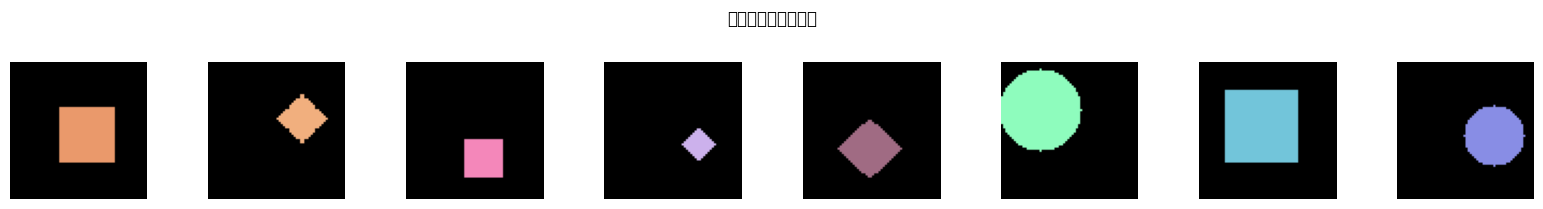

In [3]:
def make_shape_image(img_size=64):
    """生成一张包含随机彩色形状的 64x64 RGB 图像。"""
    rng = np.random.default_rng()
    img = np.zeros((img_size, img_size, 3), dtype=np.float32)

    shape_type = rng.integers(0, 3)
    color = rng.uniform(0.3, 1.0, size=3).astype(np.float32)

    cx = rng.integers(16, img_size - 16)
    cy = rng.integers(16, img_size - 16)
    r  = rng.integers(8, 20)

    if shape_type == 0:
        x0, x1 = max(0, cx - r), min(img_size, cx + r)
        y0, y1 = max(0, cy - r), min(img_size, cy + r)
        img[y0:y1, x0:x1] = color
    elif shape_type == 1:
        ys, xs = np.mgrid[0:img_size, 0:img_size]
        mask = (xs - cx) ** 2 + (ys - cy) ** 2 <= r ** 2
        img[mask] = color
    else:
        for row in range(img_size):
            half_w = int(r * (1 - abs(row - cy) / max(r, 1)))
            if half_w > 0:
                c0 = max(0, cx - half_w)
                c1 = min(img_size, cx + half_w)
                img[row, c0:c1] = color

    return torch.from_numpy(img.transpose(2, 0, 1))


class ShapeDataset(Dataset):
    def __init__(self, n_samples=1000, img_size=64, seed=42):
        torch.manual_seed(seed)
        np.random.seed(seed)
        # 将数据集存储为一个张量，以便高效索引。
        self.images = torch.stack([make_shape_image(img_size) for _ in range(n_samples)])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx]


dataset = ShapeDataset(n_samples=1000)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2 if USE_CUDA else 0,
    pin_memory=USE_CUDA,
)

print(f'数据集大小     : {len(dataset)}')
print(f'图像形状       : {dataset[0].shape}  (C, H, W)')
print(f'每轮批次数     : {len(dataloader)}')

# 健全性检查：显示几张样本图像。
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    ax.imshow(dataset[i].permute(1, 2, 0).numpy())
    ax.axis('off')
fig.suptitle('合成数据集样本图像', y=1.02)
plt.tight_layout()
plt.show()

## 2. 模型

编码器：四层步进卷积将 3x64x64 的图像压缩为潜在向量，再通过两个线性层分别输出 `mu` 和 `log_var`。

解码器：一个线性层将潜在向量展开为特征图，再经四层转置卷积重建出 3x64x64 的图像。

重参数化通过 `z = mu + sigma * epsilon`（其中 `epsilon ~ N(0, I)`）对 `z` 进行采样，使采样步骤保持可微。

In [4]:
LATENT_DIM = 32
IMG_SIZE   = 64
IMG_CH     = 3


class Encoder(nn.Module):
    """将 3x64x64 图像编码为潜在均值和对数方差。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(IMG_CH, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.flat_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(start_dim=1)
        return self.fc_mu(h), self.fc_log_var(h)


class Decoder(nn.Module):
    """将潜在向量解码回 3x64x64 图像。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.flat_dim = 256 * 4 * 4
        self.fc = nn.Linear(latent_dim, self.flat_dim)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, IMG_CH, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)
        return self.deconv(h)


class VAE(nn.Module):
    """结合编码器与解码器的变分自编码器。"""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):
        """采样 z = mu + sigma * epsilon。"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var

    def encode(self, x):
        """返回潜在均值，不进行采样。"""
        mu, _ = self.encoder(x)
        return mu

    def decode(self, z):
        return self.decoder(z)


model = VAE(latent_dim=LATENT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'总参数量       : {total_params:,}')

# 使用前向传播测试验证张量形状。
dummy = torch.zeros(4, IMG_CH, IMG_SIZE, IMG_SIZE).to(DEVICE)
recon_dummy, mu_dummy, lv_dummy = model(dummy)
print(f'输入形状       : {dummy.shape}')
print(f'mu 形状        : {mu_dummy.shape}')
print(f'log_var 形状   : {lv_dummy.shape}')
print(f'重建形状       : {recon_dummy.shape}')

总参数量       : 1,777,411
输入形状       : torch.Size([4, 3, 64, 64])
mu 形状        : torch.Size([4, 32])
log_var 形状   : torch.Size([4, 32])
重建形状       : torch.Size([4, 3, 64, 64])


## 3. ELBO 损失

ELBO 在重建质量与正则化之间取得平衡：

$$\mathcal{L} = \underbrace{\mathbb{E}[\log p(x|z)]}_{\text{重建}} - \underbrace{D_{KL}(q(z|x) \| p(z))}_{\text{正则化}}$$

重建项使用均方误差，KL 散度采用对角高斯分布的解析形式：

$$D_{KL} = -\frac{1}{2} \sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

同时追踪两个分量有助于尽早发现后验坍缩问题。

In [5]:
def elbo_loss(recon_x, x, mu, log_var, kl_weight=1.0):
    """
    ELBO 损失 = 重建损失 + KL 散度。

    返回值：
        total_loss : 标量张量（用于反向传播）
        recon_loss : 标量张量（用于日志记录）
        kl_loss    : 标量张量（用于日志记录）
    """
    # 均方重建误差。
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')

    # 对角高斯后验的解析形式 KL 散度。
    kl_loss = -0.5 * torch.mean(
        torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
    )
    # 对 KL 进行缩放，使其与重建项量级相当。
    kl_loss = kl_loss / (IMG_CH * IMG_SIZE * IMG_SIZE)

    total_loss = recon_loss + kl_weight * kl_loss
    return total_loss, recon_loss, kl_loss


# 健全性检查。
with torch.no_grad():
    sample_batch = dataset[:4].to(DEVICE)
    r, mu_, lv_ = model(sample_batch)
    total, recon, kl = elbo_loss(r, sample_batch, mu_, lv_)

print(f'初始总损失     : {total.item():.4f}')
print(f'初始重建损失   : {recon.item():.4f}')
print(f'初始 KL 损失   : {kl.item():.6f}')

初始总损失     : 0.2307
初始重建损失   : 0.2307
初始 KL 损失   : 0.000000


## 4. 训练循环

使用 Adam（`lr = 1e-3`）、批大小 64 训练 30 轮。图表采用双 y 轴，使重建损失与 KL 散度在同一图中保持可读。

In [6]:
EPOCHS     = 30
LR         = 1e-3
# elbo_loss 中 KL 已按像素数平均，权重设为 1 以上可使潜在空间
# 更接近 N(0, I)（改善先验采样和潜在遍历效果），
# 在此简单数据上对重建质量的影响可以忽略不计。
KL_WEIGHT  = 3.0

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 混合精度可加速 CUDA 训练，在 CPU 上也能正常回退。
scaler = torch.amp.GradScaler('cuda', enabled=USE_CUDA)

history_recon = []
history_kl    = []

model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_recon = 0.0
    epoch_kl    = 0.0
    n_batches   = 0

    for batch in dataloader:
        batch = batch.to(DEVICE, non_blocking=USE_CUDA)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=USE_CUDA):
            recon_batch, mu, log_var = model(batch)
            loss, recon_loss, kl_loss = elbo_loss(
                recon_batch, batch, mu, log_var, kl_weight=KL_WEIGHT
            )

        scaler.scale(loss).backward()
        optimizer_step(optimizer, scaler)

        epoch_recon += recon_loss.item()
        epoch_kl    += kl_loss.item()
        n_batches   += 1

    avg_recon = epoch_recon / n_batches
    avg_kl    = epoch_kl    / n_batches
    history_recon.append(avg_recon)
    history_kl.append(avg_kl)

    if epoch % 5 == 0 or epoch == 1:
        print(f'第 {epoch:3d}/{EPOCHS} 轮 | '
              f'重建: {avg_recon:.5f} | KL: {avg_kl:.6f}')

print('\n训练完成。')

第   1/30 轮 | 重建: 0.12738 | KL: 0.001859
第   5/30 轮 | 重建: 0.04967 | KL: 0.000430
第  10/30 轮 | 重建: 0.02139 | KL: 0.001445
第  15/30 轮 | 重建: 0.01577 | KL: 0.001555
第  20/30 轮 | 重建: 0.01367 | KL: 0.001441
第  25/30 轮 | 重建: 0.01280 | KL: 0.001343
第  30/30 轮 | 重建: 0.01238 | KL: 0.001310

训练完成。


训练预算已经确定，下面把数据集接到 epoch 迭代器和 DataLoader 上，开始按 minibatch 做优化。

/tmp/ipykernel_1550/256080877.py:22: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1550/256080877.py:22: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1550/256080877.py:22: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1550/256080877.py:22: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1550/256080877.py:22: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1550/256080877.py:22: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_1550/256080877.py:22: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missi

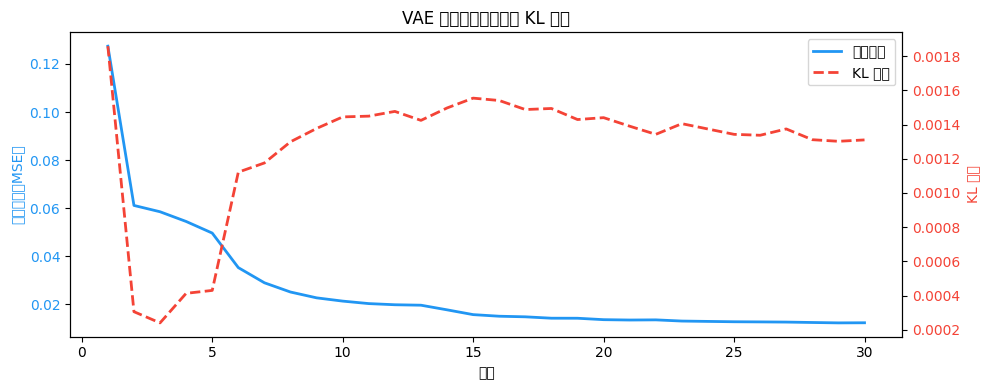

最终重建损失   : 0.01238
最终 KL 散度   : 0.001310


In [7]:
epochs_range = range(1, EPOCHS + 1)

fig, ax1 = plt.subplots(figsize=(10, 4))

color_recon = '#2196F3'
ax1.set_xlabel('轮次')
ax1.set_ylabel('重建损失（MSE）', color=color_recon)
ax1.plot(epochs_range, history_recon, color=color_recon, linewidth=2, label='重建损失')
ax1.tick_params(axis='y', labelcolor=color_recon)

ax2 = ax1.twinx()
color_kl = '#F44336'
ax2.set_ylabel('KL 散度', color=color_kl)
ax2.plot(epochs_range, history_kl, color=color_kl, linewidth=2, linestyle='--', label='KL 散度')
ax2.tick_params(axis='y', labelcolor=color_kl)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('VAE 训练：重建损失与 KL 散度')
fig.tight_layout()
plt.show()

print(f'最终重建损失   : {history_recon[-1]:.5f}')
print(f'最终 KL 散度   : {history_kl[-1]:.6f}')

优化循环搭好后，切到保留批次上比较原图和重建图，检查编码器和解码器是否真的学到了结构。

/tmp/ipykernel_1550/3254028906.py:18: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/3254028906.py:18: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/3254028906.py:18: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/3254028906.py:18: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/3254028906.py:18: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/3254028906.py:18: UserWarning: Glyph 24314 (\N{CJK UNIFIED IDEOGRAPH-5EFA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/3254028906.py:18: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}

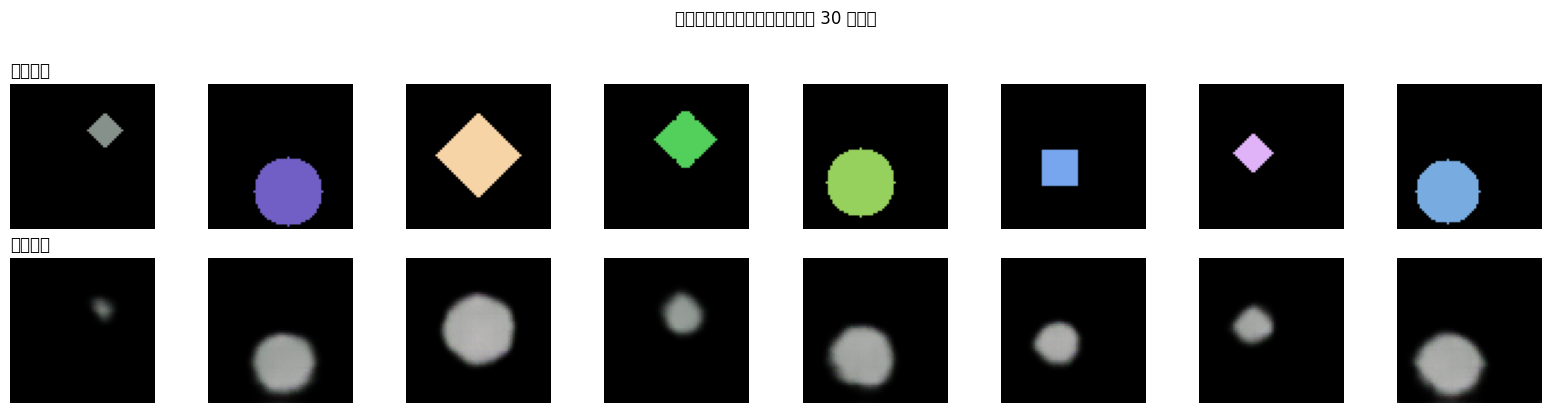

In [8]:
# 视觉对比：保留批次的原始图像与重建图像
model.eval()
with torch.no_grad():
    sample = dataset[200:208].to(DEVICE)
    recon, _, _ = model(sample)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 4))
for i in range(n_show):
    axes[0, i].imshow(sample[i].cpu().permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().permute(1, 2, 0).numpy())
    axes[1, i].axis('off')

axes[0, 0].set_title('原始图像', loc='left', fontsize=12)
axes[1, 0].set_title('重建图像', loc='left', fontsize=12)
plt.suptitle('原始图像与重建图像对比（训练 30 轮后）', y=1.02)
plt.tight_layout()
plt.show()

## 5. 潜在空间可视化

每次只改变一个潜在维度，其余维度保持为零。逐行的变化展示了解码器使用最多的方向。

/tmp/ipykernel_1550/2369424540.py:31: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/2369424540.py:31: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/2369424540.py:31: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/2369424540.py:31: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/2369424540.py:31: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/2369424540.py:31: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/2369424540.py:31: UserWarning: Glyph 36941 (\N{CJK UNIFIED IDEOGRAPH-904D}

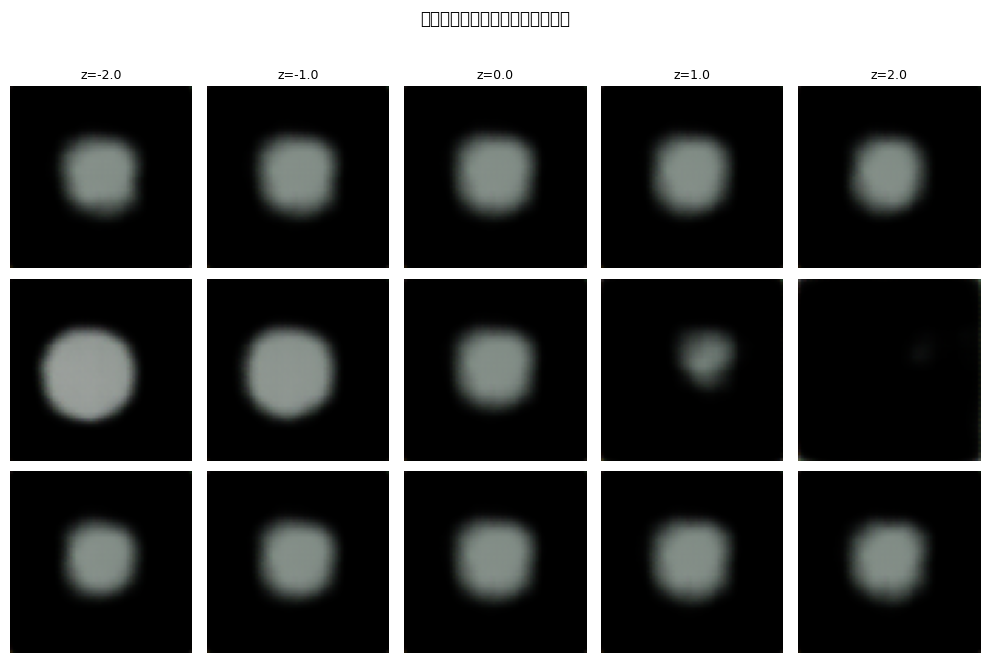

In [9]:
model.eval()

# 需要扫描的维度及扫描取值
dims_to_vary = [0, 1, 2]
sweep_values = np.linspace(-2, 2, 5)

n_rows = len(dims_to_vary)
n_cols = len(sweep_values)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2 + 0.5))

with torch.no_grad():
    for row_idx, dim in enumerate(dims_to_vary):
        for col_idx, val in enumerate(sweep_values):
            z = torch.zeros(1, LATENT_DIM, device=DEVICE)
            z[0, dim] = float(val)
            decoded = model.decode(z)  # 形状: (1, 3, 64, 64)
            img = decoded[0].cpu().permute(1, 2, 0).numpy()  # (64, 64, 3)

            ax = axes[row_idx, col_idx]
            ax.imshow(img)
            ax.axis('off')
            if col_idx == 0:
                ax.set_ylabel(f'维度 {dim}', fontsize=10, rotation=0, labelpad=30, va='center')

# 列标题
for col_idx, val in enumerate(sweep_values):
    axes[0, col_idx].set_title(f'z={val:.1f}', fontsize=9)

plt.suptitle('潜在空间遍历：每次改变一个维度', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

当重建结果稳定后，再从潜在先验里采样，看看模型在潜在空间里压缩出了什么样的形状分布。

/tmp/ipykernel_1550/831487939.py:16: UserWarning: Glyph 20174 (\N{CJK UNIFIED IDEOGRAPH-4ECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/831487939.py:16: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/831487939.py:16: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/831487939.py:16: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/831487939.py:16: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/831487939.py:16: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1550/831487939.py:16: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missi

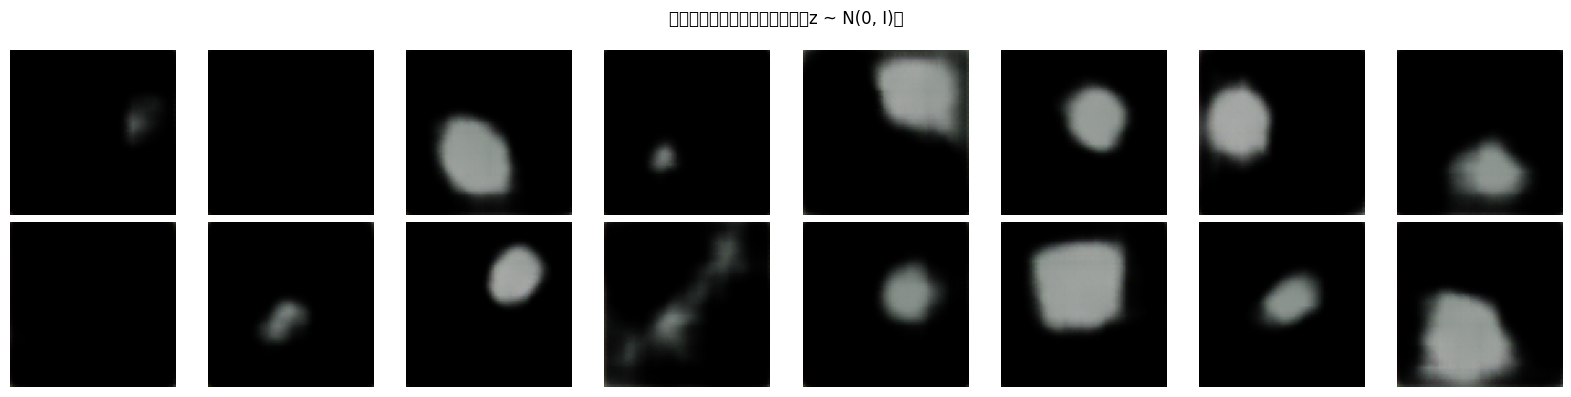

In [10]:
# 从学习到的先验中采样。
model.eval()
torch.manual_seed(42)

n_samples = 16
with torch.no_grad():
    z_random = torch.randn(n_samples, LATENT_DIM, device=DEVICE)
    samples  = model.decode(z_random)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i].cpu().permute(1, 2, 0).numpy())
    ax.axis('off')

plt.suptitle('从学习到的潜在空间随机采样（z ~ N(0, I)）', fontsize=12)
plt.tight_layout()
plt.show()

## 保存权重文件

将权重文件保存为 `vae_encoder.pt`，供 P02 和 P03 复用编码器权重。一次良好的训练应以较低的重建损失、视觉上连贯的重建结果以及对解码形状有规律影响的潜在遍历作为收尾。

In [11]:
import os

checkpoint_path = 'vae_encoder.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'encoder':          model.encoder.state_dict(),
    'decoder':          model.decoder.state_dict(),
    'latent_dim':       LATENT_DIM,
    'img_size':         IMG_SIZE,
    'img_channels':     IMG_CH,
    'final_recon_loss': history_recon[-1],
    'final_kl_loss':    history_kl[-1],
    'epochs_trained':   EPOCHS,
    'checkpoint_format': 'vae-v2',
}, checkpoint_path)

size_kb = os.path.getsize(checkpoint_path) / 1024
print(f'权重文件已保存至: {checkpoint_path}  ({size_kb:.1f} KB)')
print(f'潜在维度        : {LATENT_DIM}')
print(f'最终重建损失    : {history_recon[-1]:.5f}')
print(f'最终 KL 散度    : {history_kl[-1]:.6f}')
print()
print('在下游项目中加载的方法：')
print("  ckpt = torch.load('vae_encoder.pt', map_location='cpu')")
print("  model = VAE(latent_dim=ckpt['latent_dim'])")
print("  model.load_state_dict(ckpt['model_state_dict'])")

权重文件已保存至: vae_encoder.pt  (6954.4 KB)
潜在维度        : 32
最终重建损失    : 0.01238
最终 KL 散度    : 0.001310

在下游项目中加载的方法：
  ckpt = torch.load('vae_encoder.pt', map_location='cpu')
  model = VAE(latent_dim=ckpt['latent_dim'])
  model.load_state_dict(ckpt['model_state_dict'])
